In [53]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

In [54]:
DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-gauss" / "snapshots"
FILE_PATH = DATA_DIR / "Poisson-Gauss.nc" 
FILE_MORE_PARAMS_PATH = DATA_DIR / "poisson_gauss_parameters.csv"

In [55]:
epochs = 3
batch_size = 1024
alpha = 1e-4 # Kaczmarz relaxation parameter
M = 3000 # tied to out_features, num_frequencies and no. of linear weights
chunk_size = 1000
hidden_layers = [256, 256, 256, 256] # scale up when scaling M up 

Dataset summary:
<xarray.Dataset> Size: 3GB
Dimensions:   (sample: 20000, x: 128, y: 128)
Dimensions without coordinates: sample, x, y
Data variables:
    solution  (sample, x, y) float32 1GB ...
    source    (sample, x, y) float32 1GB ...

Extracted Source Shape: (128, 128)
Extracted Solution Shape: (128, 128)


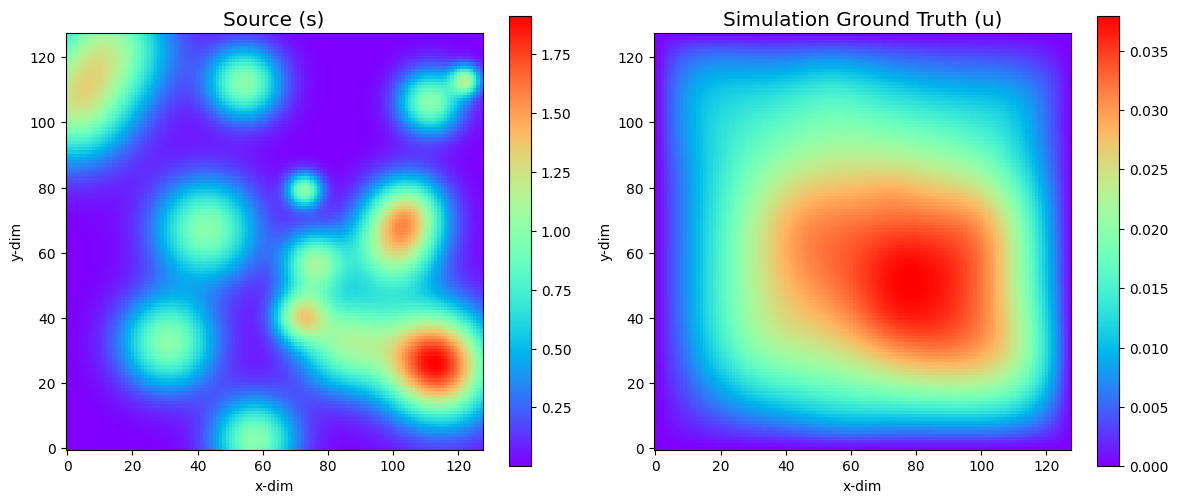

In [56]:
import xarray as xr

ds = xr.open_dataset(FILE_PATH)
print(f"Dataset summary:\n{ds}\n")

sample_idx = 19808

source_sample = ds['source'][sample_idx].values
solution_sample = ds['solution'][sample_idx].values

print(f"Extracted Source Shape: {source_sample.shape}")
print(f"Extracted Solution Shape: {solution_sample.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(source_sample.T, origin='lower', cmap='rainbow')
fig.colorbar(im1, ax=axes[0])
axes[0].set_title('Source (s)', fontsize='x-large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

im2 = axes[1].imshow(solution_sample.T, origin='lower', cmap='rainbow')
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')
plt.tight_layout()
plt.show()

ds.close()

In [57]:
"""
Creating a new dataset with param information
"""
from skimage.feature import peak_local_max
from scipy.optimize import curve_fit

def multi_gaussian_2d(coords, *params):
    x, y = coords
    result = np.zeros_like(x, dtype=float)
    for i in range(0, len(params), 3):
        mu_x, mu_y, sigma = params[i:i+3]
        result += np.exp(-((x - mu_x)**2 + (y - mu_y)**2) / (2 * sigma**2))
    return result.ravel()

if not FILE_MORE_PARAMS_PATH.exists():
    ds = xr.open_dataset(FILE_PATH)
    source_data = ds['source'].values
    ds.close()

    nx, ny = source_data.shape[1], source_data.shape[2]
    x_grid, y_grid = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')

    results = []
    print(f"Extracting for {len(source_data)} samples...")

    sigma_min_px = 0.025 * nx
    sigma_max_px = 0.1 * nx
    sigma_guess_px = 0.0625 * nx

    for idx, sample in enumerate(tqdm(source_data, desc="Extracting Parameters")):
        row_data = {'sample_idx': idx}
        
        peak_indices = peak_local_max(sample, min_distance=5, threshold_rel=0.1, exclude_border=False)
        N = len(peak_indices)
        row_data['N'] = N
        
        initial_guess = []
        lower_bounds = []
        upper_bounds = []

        for px, py in peak_indices:
            initial_guess.extend([px, py, sigma_guess_px])
            lower_bounds.extend([0, 0, sigma_min_px])
            upper_bounds.extend([nx, ny, sigma_max_px])
            
        popt, _ = curve_fit(
            multi_gaussian_2d, 
            (x_grid, y_grid), 
            sample.ravel(), 
            p0=initial_guess,
            bounds=(lower_bounds, upper_bounds)
        )
        
        # raw pixel parameters for this specific sample, need to normalize later
        for i in range(N):
            fit_mu_x, fit_mu_y, fit_sigma_pixels = popt[i*3 : (i+1)*3]
            
            row_data[f'mu_x_{i}'] = fit_mu_x 
            row_data[f'mu_y_{i}'] = fit_mu_y 
            row_data[f'sigma_{i}'] = fit_sigma_pixels 
                
        results.append(row_data)

    df = pd.DataFrame(results)
    df.to_csv(FILE_MORE_PARAMS_PATH, index=False)
    print(f"\nExtraction complete! Data saved to: {FILE_MORE_PARAMS_PATH}")

In [58]:
df = pd.read_csv(FILE_MORE_PARAMS_PATH)
df = df.fillna(0.0)

mu_x_cols = [col for col in df.columns if col.startswith('mu_x')]
N_max = len(mu_x_cols)
print(f"Network will accept a maximum of {N_max} peaks.")

Network will accept a maximum of 18 peaks.


In [59]:
df.head()

,sample_idx,N,mu_x_0,mu_y_0,sigma_0,mu_x_1,mu_y_1,sigma_1,mu_x_2,mu_y_2,...,sigma_14,mu_x_15,mu_y_15,sigma_15,mu_x_16,mu_y_16,sigma_16,mu_x_17,mu_y_17,sigma_17
0,0,2,103.691956,2.107274,8.988455,5.224124,34.397806,11.915725,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2,3.112036,107.844472,12.309281,119.221734,69.312186,10.164830,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1,51.580360,6.632716,5.085781,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,1,38.083757,73.992379,9.613451,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,1,46.551546,120.119422,4.196299,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
class PoissonGaussDataset(Dataset):
    def __init__(self, source_data, solution_data, parameters):
        # Reshape (N, 128, 128) to (N, 16384, 1)
        self.s = source_data.reshape(source_data.shape[0], -1, 1)
        self.u = solution_data.reshape(solution_data.shape[0], -1, 1)
        self.p = parameters

    def __len__(self):
        return len(self.p)

    def __getitem__(self, idx):
        return self.s[idx], self.u[idx], self.p[idx]

param_cols = [col for col in df.columns if col != 'sample_idx']
all_params = np.array(df[param_cols].values) / 128.0  # Normalize to [0, 1], shape: (20000, 3 * N_max), N_max = 18

ds = xr.open_dataset(FILE_PATH)
all_source = ds['source'].values
all_solution = ds['solution'].values
ds.close()

n_train = 19640
n_val = 120
n_test = 240

train_dataset = PoissonGaussDataset(
    source_data=all_source[:n_train], 
    solution_data=all_solution[:n_train], 
    parameters=all_params[:n_train]
)

val_dataset = PoissonGaussDataset(
    source_data=all_source[n_train : n_train + n_val], 
    solution_data=all_solution[n_train : n_train + n_val], 
    parameters=all_params[n_train : n_train + n_val]
)

test_dataset = PoissonGaussDataset(
    source_data=all_source[-n_test:], 
    solution_data=all_solution[-n_test:], 
    parameters=all_params[-n_test:]
)

# We use batch_size=8 here meaning 8 complete samples (and their 16384 points) per batch.
batch_size_samples = 8 
train_dataloader = jd.DataLoader(
    train_dataset, 
    backend='pytorch', 
    batch_size=batch_size_samples, 
    shuffle=True, 
    drop_last=True,
    num_workers=0
)

val_dataloader = jd.DataLoader(
    val_dataset, 
    backend='pytorch', 
    batch_size=batch_size_samples, 
    shuffle=False, 
    num_workers=0 
)

test_dataloader = jd.DataLoader(
    test_dataset, 
    backend='pytorch', 
    batch_size=batch_size_samples, 
    shuffle=False, 
    num_workers=0 
)

print(f"DataLoaders ready!")

DataLoaders ready!


In [61]:
nx, ny = source_sample.shape # 128, 128

# normalize
x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)

X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

s = jnp.array(source_sample.reshape(-1, 1), dtype=jnp.float64)
u_sim = jnp.array(solution_sample.reshape(-1, 1), dtype=jnp.float64)

# Dirichlet Boundary Condition
x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() # Array([ True,  True,  True, ..., False, False, False], dtype=bool)
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top # an array of True if on boundary, False if not on boundary.

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]

u_bc = jnp.zeros_like(x_bc) # Dirichlet u=0


In [62]:
# Setup the RFF Matrix
num_frequencies = M
sigma = 0.5 

rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, num_frequencies)) * sigma

# class FeatureExtractor(nn.Module):
#     hidden_layers: list
#     out_features: int
#     B_matrix: jnp.ndarray # Frozen random projection matrix
    
#     @nn.compact
#     def __call__(self, x_in, y_in, p_in):
#         x_val = jnp.squeeze(x_in)
#         y_val = jnp.squeeze(y_in)
#         v = jnp.stack([x_val, y_val])
        
#         proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
#         p_val = jnp.squeeze(p_in)
#         h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

#         for size in self.hidden_layers:
#             h_concat = jnp.concatenate([h, p_val]) # Inject parameters before every hidden layer
#             h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h_concat)
#             h = nn.tanh(h) 
            
#         features = nn.Dense(self.out_features, kernel_init=nn.initializers.he_normal())(h)
#         return features

class FeatureExtractor(nn.Module):
    hidden_layers: list
    out_features: int
    B_matrix: jnp.ndarray # Frozen random projection matrix
    
    @nn.compact
    def __call__(self, x_in, y_in, p_in):
        x_val = jnp.squeeze(x_in)
        y_val = jnp.squeeze(y_in)
        v = jnp.stack([x_val, y_val])
        
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        p_val = jnp.squeeze(p_in)
        
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            
            # FiLM Modulation: Generate scale (gamma) and shift (beta) from parameters
            # gamma = nn.Dense(size, kernel_init=nn.initializers.ones)(p_val) <<<< This one caused exploding gradients, so we do the try the method below
            gamma = 1.0 + nn.Dense(size, kernel_init=nn.initializers.zeros)(p_val)
            beta = nn.Dense(size, kernel_init=nn.initializers.zeros)(p_val)
            
            # Apply FiLM conditioning and activation
            h = gamma * h + beta
            h = nn.tanh(h) 
            
        features = nn.Dense(self.out_features, kernel_init=nn.initializers.he_normal())(h)
        return features
    
model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    out_features=M,
    B_matrix=B_matrix 
)

# Dummy initialization to get the shapes right
key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
dummy_p = all_params[0] 
params = model.init(key, dummy_x, dummy_y, dummy_p)

def get_f(params, x_val, y_val, p_val):
    return model.apply(params, x_val, y_val, p_val)

def get_f_dir(params, x_val, y_val, p_val):
    f = get_f(params, x_val, y_val, p_val)
    
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val, p_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val, p_val)
    
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2, -3))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2, -3))

    return f_xx, f_yy

def get_f_chunk(params, x_val, y_val, p_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val, p_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, p_val, start_idx, end_idx):
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, p_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, p_val, start_idx, end_idx)
    
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    
    return f_xx_chunk, f_yy_chunk

def get_u(params, x_val, y_val, p_val, w_current):
    # f shape: (m,)
    f = model.apply(params, x_val, y_val, p_val)
    # Return scalar: dot product of f and w
    return jnp.dot(f, w_current) 

def get_u_dir(params, x_val, y_val, p_val, w_current):
    u_xx = jacfwd(jacfwd(get_u, argnums=1), argnums=1)(params, x_val, y_val, p_val, w_current)
    u_yy = jacfwd(jacfwd(get_u, argnums=2), argnums=2)(params, x_val, y_val, p_val, w_current)
    
    u_xx = jnp.squeeze(u_xx, axis=(-1, -2))
    u_yy = jnp.squeeze(u_yy, axis=(-1, -2))
    
    return u_xx, u_yy

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0, None))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0, None))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None, None))

In [63]:
optimizer = optax.adamw(learning_rate=1e-4, weight_decay=1e-4)

# freeze final linear layer weights
def compute_loss_single(params, w_current, x_batch, y_batch, s_single, x_bc, y_bc, u_bc, p_single):
    u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, p_single, w_current)
    laplacian_u = u_xx + u_yy
    
    pde_residual = laplacian_u + s_single
    loss_pde = jnp.mean(pde_residual ** 2)
    
    # Boundary Condition Loss (Dirichlet u = 0) 
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc, p_single)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    loss_bc = jnp.mean((u_bc_pred - u_bc) ** 2) * 1000.0
    
    return loss_pde + loss_bc

# VMAP the loss over the batch of sources and parameters
batched_compute_loss = jax.vmap(
    compute_loss_single, 
    in_axes=(None, None, None, None, 0, None, None, None, 0)
)

# Take the mean of the batched losses and get gradients
loss_grad_fn = jax.jit(value_and_grad(lambda *args: jnp.mean(batched_compute_loss(*args)), argnums=0))

@jax.jit
def update_hidden(params, opt_state, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, p_batch):
    # Now we safely pass p_batch into our gradient function
    loss, grads = loss_grad_fn(params, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, p_batch)
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, opt_state, loss

In [64]:
"""
@jit
def kaczmarz_step(A_B, b_B, w_current, alpha, batch_weight_decay): 
    block_size = A_B.shape[0]
    r = A_B @ w_current - b_B
    gram = A_B @ A_B.T + 1e-6 * jnp.eye(block_size)
    z = jnp.linalg.solve(gram, r)    
    w_new = w_current - alpha * (A_B.T @ z)
    # w_new = (1.0 - batch_weight_decay) * w_current - alpha * (A_B.T @ z) <<< If we require weight decay for linear weights
    return w_new

@jit
def build_and_update_kaczmarz(params, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, alpha, batch_weight_decay):
    
    f_xx, f_yy = f_dir_vmap(params, x_batch, y_batch)
    A_pde = f_xx + f_yy
    b_pde = -s_batch

    A_bc = f_vmap(params, x_bc, y_bc) * jnp.sqrt(1000.0)
    b_bc = u_bc * jnp.sqrt(1000.0)
    
    A_block = jnp.vstack([A_pde, A_bc])
    b_block = jnp.vstack([b_pde, b_bc])
    
    w_updated = kaczmarz_step(A_block, b_block, w_current, alpha, batch_weight_decay)
    return w_updated
"""

def get_A_and_w_chunk(params, w_current, x_batch, y_batch, x_bc, y_bc, p_single, start_idx, chunk_size, M_total):
    """
    To get chunked A_b and w
    """
    end_idx = min(start_idx + chunk_size, M_total)
    
    f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_batch, y_batch, p_single, start_idx, end_idx)
    A_pde_chunk = f_xx + f_yy
    
    A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, p_single, start_idx, end_idx) * jnp.sqrt(1000.0)
    
    A_chunk = jnp.vstack([A_pde_chunk, A_bc_chunk])
    w_chunk = w_current[start_idx:end_idx]
    
    return A_chunk, w_chunk

def build_and_update_kaczmarz_single(params, w_current, x_batch, y_batch, s_single, x_bc, y_bc, u_bc, p_single, alpha, M_total, chunk_size):
    N_total = x_batch.shape[0] + x_bc.shape[0]
    
    Gram = jnp.zeros((N_total, N_total))
    Aw = jnp.zeros((N_total, 1))
    
    b_pde = -s_single
    b_bc = u_bc * jnp.sqrt(1000.0)
    b_B = jnp.vstack([b_pde, b_bc])

    # Calculate right side of update equation
    for start_idx in range(0, M_total, chunk_size):
        A_chunk, w_chunk = get_A_and_w_chunk(params, w_current, x_batch, y_batch, x_bc, y_bc, p_single, start_idx, chunk_size, M_total)
        Gram += A_chunk @ A_chunk.T
        Aw += A_chunk @ w_chunk

    r = Aw - b_B
    z = jnp.linalg.solve(Gram + 1e-6 * jnp.eye(N_total), r)
    
    # Calculate left side of update equation
    w_new_list = []
    for start_idx in range(0, M_total, chunk_size):
        A_chunk, w_chunk = get_A_and_w_chunk(params, w_current, x_batch, y_batch, x_bc, y_bc, p_single, start_idx, chunk_size, M_total)
        w_chunk_new = w_chunk - alpha * (A_chunk.T @ z)
        w_new_list.append(w_chunk_new)
        
    return jnp.vstack(w_new_list)

batched_kaczmarz = jax.vmap(
    build_and_update_kaczmarz_single, 
    in_axes=(None, None, None, None, 0, None, None, None, 0, None, None, None)
)

@jax.jit(static_argnames=['M_total', 'm_chunk_size'])
def update_kaczmarz_batch(params, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, p_batch, alpha, M_total, m_chunk_size):
    w_new_batch = batched_kaczmarz(params, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, p_batch, alpha, M_total, m_chunk_size)
    return jnp.mean(w_new_batch, axis=0)

In [65]:
# pass full x_grid and y_grid to every sample but slice the p_batch
batched_predict = jax.vmap(f_spatial_vmap, in_axes=(None, None, None, 0))

@jax.jit
def fast_eval_step(params, w_current, x_grid, y_grid, u_batch, p_batch):
    """Evaluate an entire batch"""
    # shape (batch_size, 16384, M)
    f_batch = batched_predict(params, x_grid, y_grid, p_batch)
    
    # Broadcast (batch_size, 16384, M) @ (M, 1) -> (batch_size, 16384, 1)
    u_pred_batch = f_batch @ w_current
    
    return jnp.mean((u_pred_batch - u_batch)**2)

def evaluate_dataset(dataloader, params, w_current, x_grid, y_grid):
    """Calculates the average MSE across an entire dataloader"""
    total_mse = 0.0
    total_samples = 0
    
    for _, u_batch, p_batch in dataloader:
        batch_mse = fast_eval_step(params, w_current, x_grid, y_grid, u_batch, p_batch)
        
        current_batch_size = p_batch.shape[0]
        
        total_mse += batch_mse.item() * current_batch_size
        total_samples += current_batch_size
            
    return total_mse / total_samples

In [ ]:
w = jnp.zeros((M, 1))
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0] # 16384
spatial_batch_size = 1000 # N batching

rng, shuffle_key = jax.random.split(rng)
spatial_indices = jax.random.permutation(shuffle_key, total_points)
ptr = 0 # Global pointer for the spatial grid

for epoch in range(epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    for s_batch, u_batch, p_batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        
        # If we reach the end of the grid, reshuffle and reset the pointer
        if ptr + spatial_batch_size > total_points:
            rng, shuffle_key = jax.random.split(rng)
            spatial_indices = jax.random.permutation(shuffle_key, total_points)
            ptr = 0
            
        # Get next 1000 points without replacement
        batch_idx = spatial_indices[ptr : ptr + spatial_batch_size]
        ptr += spatial_batch_size
        
        x_chunk = x[batch_idx]
        y_chunk = y[batch_idx]
        
        # Shape becomes: (8, 1000, 1)
        s_chunk = s_batch[:, batch_idx, :]
        
        # one update per batch of samples
        w = update_kaczmarz_batch(params, w, x_chunk, y_chunk, s_chunk, x_bc, y_bc, u_bc, p_batch, alpha, M, chunk_size)
        params, opt_state, loss = update_hidden(params, opt_state, w, x_chunk, y_chunk, s_chunk, x_bc, y_bc, u_bc, p_batch)
        
        epoch_loss += loss
        num_batches += 1
            
    avg_train_loss = epoch_loss / num_batches
    
    val_mse = evaluate_dataset(val_dataloader, params, w, x, y)
    print(f"Epoch {epoch+1:03d} | Train Loss (PDE+BC): {avg_train_loss:.4e} | Validation MSE: {val_mse:.4e}")

Epoch 1/3:   0%|          | 0/2455 [00:00<?, ?it/s]

In [ ]:
# The very long training run with all points sampled for all samples
# 
# w = jnp.zeros((M, 1))
# opt_state = optimizer.init(params)
# rng = jax.random.PRNGKey(42)

# total_points = x.shape[0] # 16384
# spatial_batch_size = 1000 # N batching

# for epoch in range(epochs):
#     epoch_loss = 0.0
#     num_batches = 0
    
#     # For 8 samples
#     for s_batch, u_batch, p_batch in tqdm(train_dataloader, desc=f"Epoch {epoch}/{epochs}"):
        
#         # Shuffle indices for the PDE points for this batch of samples
#         rng, shuffle_key = jax.random.split(rng)
#         indices = jax.random.permutation(shuffle_key, total_points) 
        
#         # sample coordinates without replacement
#         for i in range(0, total_points, spatial_batch_size):
#             batch_idx = indices[i : i + spatial_batch_size] 
            
#             x_chunk = x[batch_idx]
#             y_chunk = y[batch_idx]
            
#             # Shape (8, spatial_batch_size, 1)
#             s_chunk = s_batch[:, batch_idx, :]
            
#             # Update Linear Weights (w) - Passes full x_bc and y_bc
#             w = update_kaczmarz_batch(params, w, x_chunk, y_chunk, s_chunk, x_bc, y_bc, u_bc, p_batch, alpha, M, chunk_size)

#             # Update Hidden Weights (params)
#             params, opt_state, loss = update_hidden(params, opt_state, w, x_chunk, y_chunk, s_chunk, x_bc, y_bc, u_bc, p_batch)
            
#             epoch_loss += loss
#             num_batches += 1
            
#     avg_train_loss = epoch_loss / num_batches
    
#     if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
#         val_mse = evaluate_dataset(val_dataloader, params, w, x, y)
#         print(f"Epoch {epoch+1:03d} | Train Loss (PDE+BC): {avg_train_loss:.4e} | Validation MSE: {val_mse:.4e}")

# print("\n=== Training Complete. Running Final Test... ===")
# final_test_mse = evaluate_dataset(test_dataloader, params, w, x, y)

# print(f"FINAL TEST MSE: {final_test_mse:.4e}")

In [ ]:
# The original 1 sample only training loop

# total_points = x.shape[0]

# # epoch_weight_decay = 1e-4  # for linear weights
# # N = int(np.ceil(total_points / batch_size)) # Number of batches per epoch
# # batch_weight_decay = 1.0 - (1.0 - epoch_weight_decay) ** (1.0 / N)

# w = jnp.zeros((M, 1))
# opt_state = optimizer.init(params)
# rng = jax.random.PRNGKey(42)
        
# for epoch in tqdm(range(epochs), desc=f"Training {epochs} Epochs"):
#     rng, shuffle_key = jax.random.split(rng)
    
#     indices = jax.random.permutation(shuffle_key, total_points) # shuffled indices for the PDE points
    
#     epoch_loss = 0.0
#     num_batches = 0
    
#     # Process the domain in chunks (mini-batches)
#     for i in range(0, total_points, batch_size):
#         batch_idx = indices[i : i + batch_size] # sampling without replacement for 1 epoch
        
#         x_batch = x[batch_idx]
#         y_batch = y[batch_idx]
#         s_batch = s[batch_idx]
        
#         # NOTE: We are passing the full boundary condition arrays (x_bc, y_bc) into 
#         # every step here. If it is too much, we should use cyclic sampling of bc with mini-batching.
        
#         # Update Linear Weights (w)
#         # w = build_and_update_kaczmarz(params, w, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, alpha, batch_weight_decay)
#         w = build_and_update_kaczmarz_chunked(params, w, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, alpha, M, chunk_size)

#         # Update Hidden Weights (params)
#         params, opt_state, loss = update_hidden(params, opt_state, w, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc)
        
#         epoch_loss += loss
#         num_batches += 1
        
#     avg_loss = epoch_loss / num_batches
    
#     if epoch % 10 == 0 or epoch == epochs - 1:
#         # Calculate full-grid MSE with frozen w and params
#         f_all = f_vmap(params, x, y)
#         u_pred = f_all @ w
#         mse = jnp.mean((u_pred - u_sim)**2)
        
#         print(f"Epoch {epoch:03d} | PDE/BC Loss: {avg_loss:.4e} | Full Grid MSE vs Ground Truth: {mse:.4e}")

# print("Training Complete!")

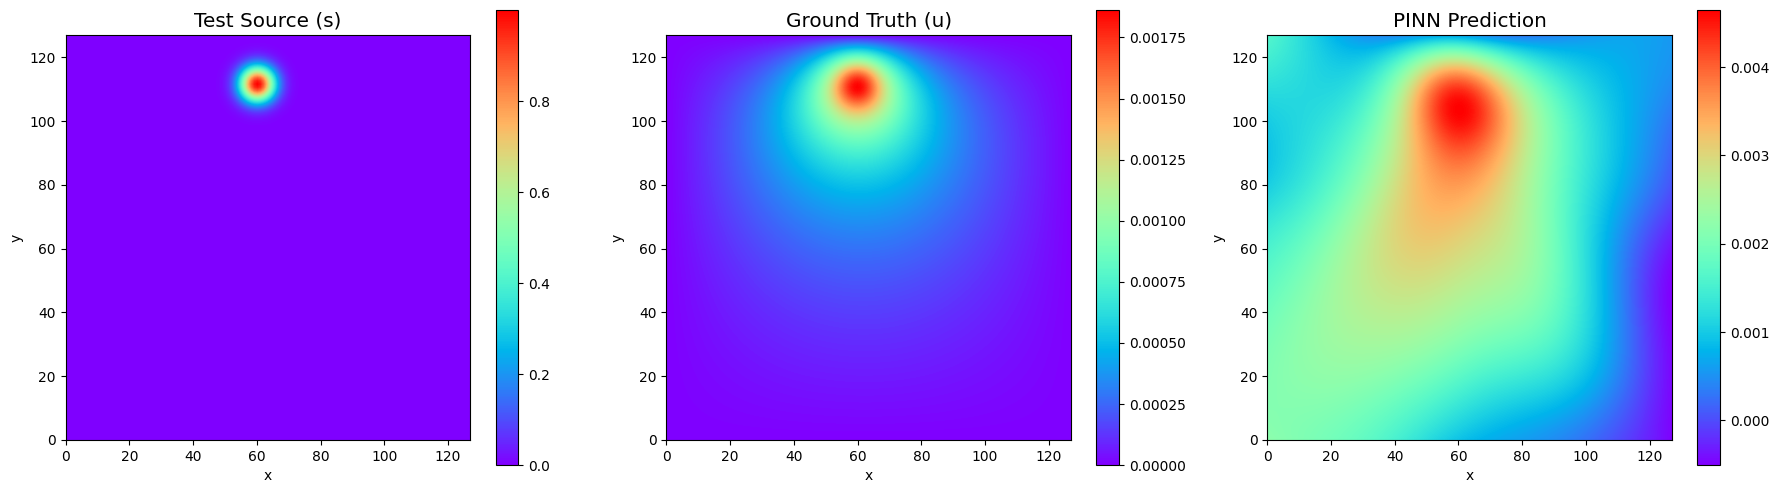

In [ ]:
s_sample, u_sim_sample, p_sample = test_dataset[121]

f_features = f_spatial_vmap(params, x, y, p_sample)
u_pred = f_features @ w

s_plot = s_sample.reshape(nx, ny).T
u_sim_plot = u_sim_sample.reshape(nx, ny).T 
u_pred_plot = u_pred.reshape(nx, ny).T

ext = [0, nx - 1, 0, ny - 1]
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
mesh1 = ax1.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=ax1)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Test Source (s)', fontsize='x-large')

ax2 = fig.add_subplot(1, 3, 2)
mesh2 = ax2.imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=ax2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Ground Truth (u)', fontsize='x-large')

ax3 = fig.add_subplot(1, 3, 3)
mesh3 = ax3.imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=ax3)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('PINN Prediction', fontsize='x-large')

plt.tight_layout()
plt.show()